# Name: I Made Bimantoro Mastra
# Assignment Day 24 - Regularized Regression in Python


---
## 1. Pengumpulan Data

**Goals:** Memahami struktur dataset dan signifikansi masing-masing variabel.


In [ ]:
# Import library
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Supaya grafik terlihat lebih rapi
sns.set_style("whitegrid")

# Load data
df = pd.read_csv("/content/sample_data/boston.csv")


df.head()


,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,black,lstat,medv
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222,18.7,396.90,5.33,36.2


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 506 entries, 0 to 505
Data columns (total 14 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   crim     506 non-null    float64
 1   zn       506 non-null    float64
 2   indus    506 non-null    float64
 3   chas     506 non-null    int64  
 4   nox      506 non-null    float64
 5   rm       506 non-null    float64
 6   age      506 non-null    float64
 7   dis      506 non-null    float64
 8   rad      506 non-null    int64  
 9   tax      506 non-null    int64  
 10  ptratio  506 non-null    float64
 11  black    506 non-null    float64
 12  lstat    506 non-null    float64
 13  medv     506 non-null    float64
dtypes: float64(11), int64(3)
memory usage: 55.5 KB


In [ ]:
df.duplicated().sum()

np.int64(0)

### Penjelasan Variabel (Kolom)

Setiap baris pada dataset ini mewakili satu wilayah/permukiman.

| Kolom | Arti |
|---|---|
| `crim` | Tingkat kriminalitas per kapita di wilayah tersebut |
| `zn` | Proporsi lahan permukiman yang dizonasi untuk lot besar (>25.000 sq.ft) |
| `indus` | Proporsi luas lahan non-ritel (industri) di wilayah tersebut |
| `chas` | Variabel dummy: 1 jika berbatasan dengan Sungai Charles, 0 jika tidak |
| `nox` | Konsentrasi nitrogen oksida (polusi udara) |
| `rm` | Rata-rata jumlah ruangan per rumah |
| `age` | Proporsi rumah yang dibangun sebelum tahun 1940 |
| `dis` | Jarak tertimbang ke 5 pusat pekerjaan di Boston |
| `rad` | Indeks aksesibilitas ke jalan tol radial |
| `tax` | Tarif pajak properti per $10.000 |
| `ptratio` | Rasio murid-guru di wilayah tersebut |
| `black` | Proporsi penduduk kulit hitam |
| `lstat` | Persentase penduduk dengan status sosial-ekonomi rendah |
| `medv` | **Target/label** — nilai median harga rumah (dalam ribuan USD) |

**Relevansi terhadap studi kasus prediksi harga rumah:**

`medv` (variabel dependen/target) adalah variabel yang ingin diprediksi, kolom sisanya adalah variabel independen. Secara logika bisnis, harga rumah biasanya dipengaruhi oleh:
- **Kualitas fisik rumah**: `rm` (jumlah kamar) dan `age` (usia bangunan)
- **Lingkungan sekitar**: `crim` (kriminalitas), `nox` (polusi), `indus` (kawasan industri), `chas` (dekat sungai)
- **Aksesibilitas & fasilitas**: `dis` (jarak ke pusat kerja), `rad` (akses jalan tol), `ptratio` (kualitas sekolah)
- **Faktor ekonomi**: `tax` (pajak properti), `lstat` (status sosial-ekonomi sekitar)

Biasanya kawasan rumah yang memiliki tingkat kriminalitas rendah, posisi strategis dan juga punya banyak kamar memang cenderung lebih mahal.


In [ ]:
# Cek statistik deskriptif untuk melihat skala & sebaran tiap variabel
df.describe()


,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,black,lstat,medv
count,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000
mean,3.613524,11.363636,11.136779,0.069170,0.554695,6.284634,68.574901,3.795043,9.549407,408.237154,18.455534,356.674032,12.653063,22.532806
std,8.601545,23.322453,6.860353,0.253994,0.115878,0.702617,28.148861,2.105710,8.707259,168.537116,2.164946,91.294864,7.141062,9.197104
min,0.006320,0.000000,0.460000,0.000000,0.385000,3.561000,2.900000,1.129600,1.000000,187.000000,12.600000,0.320000,1.730000,5.000000
25%,0.082045,0.000000,5.190000,0.000000,0.449000,5.885500,45.025000,2.100175,4.000000,279.000000,17.400000,375.377500,6.950000,17.025000
50%,0.256510,0.000000,9.690000,0.000000,0.538000,6.208500,77.500000,3.207450,5.000000,330.000000,19.050000,391.440000,11.360000,21.200000
75%,3.677083,12.500000,18.100000,0.000000,0.624000,6.623500,94.075000,5.188425,24.000000,666.000000,20.200000,396.225000,16.955000,25.000000
max,88.976200,100.000000,27.740000,1.000000,0.871000,8.780000,100.000000,12.126500,24.000000,711.000000,22.000000,396.900000,37.970000,50.000000


In [ ]:
# Hitung korelasi setiap fitur terhadap target (medv).
korelasi_ke_medv = df.corr()["medv"].sort_values(key=abs, ascending=False)
# key=abs pengurutan dilakukan berdasarkan nilai absolut (mengabaikan tanda plus/minus).
# ascending=False untuk urutkan dari paling besar ke paling kecil (paling kuat dulu).
korelasi_ke_medv


,medv
medv,1.000000
lstat,-0.737663
rm,0.695360
ptratio,-0.507787
indus,-0.483725
tax,-0.468536
nox,-0.427321
crim,-0.388305
rad,-0.381626
age,-0.376955


| Rentang nilai (absolut) | Kekuatan |
|---|---|
| 0.7 – 1.0 | Kuat |
| 0.4 – 0.7 | Sedang |
| 0.1 – 0.4 | Lemah |
| 0 – 0.1 | Hampir tidak ada hubungan |


---



**Interpretasi hasil korelasi terhadap `medv`:**

Dari tabel korelasi di atas, kita bisa melihat variabel mana yang paling "berbicara" terhadap harga rumah:

- **`lstat` (korelasi negatif kuat, sekitar -0.74)** = semakin tinggi persentase penduduk berstatus ekonomi rendah di suatu area, semakin rendah harga rumah. Ini variabel paling relevan kedua.
- **`rm` (korelasi positif kuat, sekitar +0.70)** = semakin banyak jumlah kamar rata-rata, semakin tinggi harga rumah. Variabel paling relevan karena menunjukan ukuran/kemewahan rumah secara langsung.
- **`ptratio` (korelasi negatif sedang, sekitar -0.51)** = rasio murid-guru yang tinggi berasosiasi dengan harga rumah lebih rendah. Masih banyak variasi harga rumah yang tidak bisa dijelaskan hanya dari ptratio saja.
- **`tax` dan `indus`** juga berkorelasi negatif sedang = kawasan dengan pajak tinggi dan banyak industri cenderung punya rumah lebih murah.
- Variabel seperti **`chas`** dan **`dis`** korelasinya sangat lemah terhadap `medv` secara individual, tapi bukan berarti tidak berguna hanya kontribusinya tidak terlalu signifikan untuk menentukan harga rumah.

**Kesimpulan **
Faktor penentu harga rumah yaitu variabel **`rm`** dan **`lstat`** yang paling relevan untuk dijadikan fokus utama, karena keduanya punya hubungan linear paling kuat (baik positif maupun negatif) dengan `medv`.


---
## 2. Persiapan Data

**Goals:** Memastikan data siap digunakan untuk membangun model prediksi.


In [ ]:
# Cek apakah ada nilai yang hilang (missing value) di dataset
df.isnull().sum()


,0
crim,0
zn,0
indus,0
chas,0
nox,0
rm,0
age,0
dis,0
rad,0
tax,0


dataset **tidak ada missing value**.


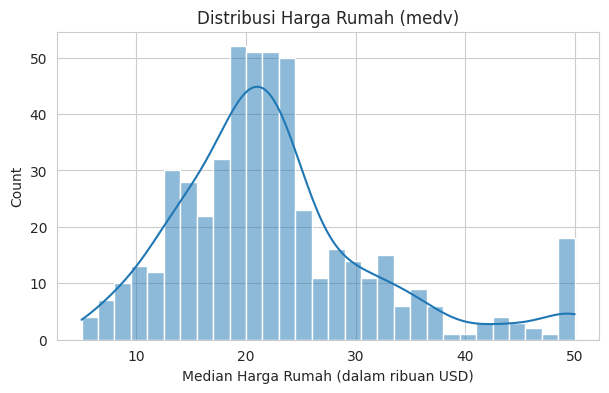

In [ ]:
# Eksplorasi awal: lihat distribusi target (medv) dengan histogram
plt.figure(figsize=(7,4))
sns.histplot(df["medv"], bins=30, kde=True)
plt.title("Distribusi Harga Rumah (medv)")
plt.xlabel("Median Harga Rumah (dalam ribuan USD)")
plt.show()


Dari histogram terlihat distribusi `medv` sedikit **miring ke kanan (right-skewed)**, dengan mayoritas harga berkisar 15-25 (ribu USD), tapi ada beberapa rumah bernilai sangat tinggi (>45).


In [ ]:
# Pisahkan fitur (X) dan target (y)
X = df.drop(columns=["medv"])
y = df["medv"]

print("Jumlah fitur:", X.shape[1])
print("Jumlah baris:", X.shape[0])


Jumlah fitur: 13
Jumlah baris: 506


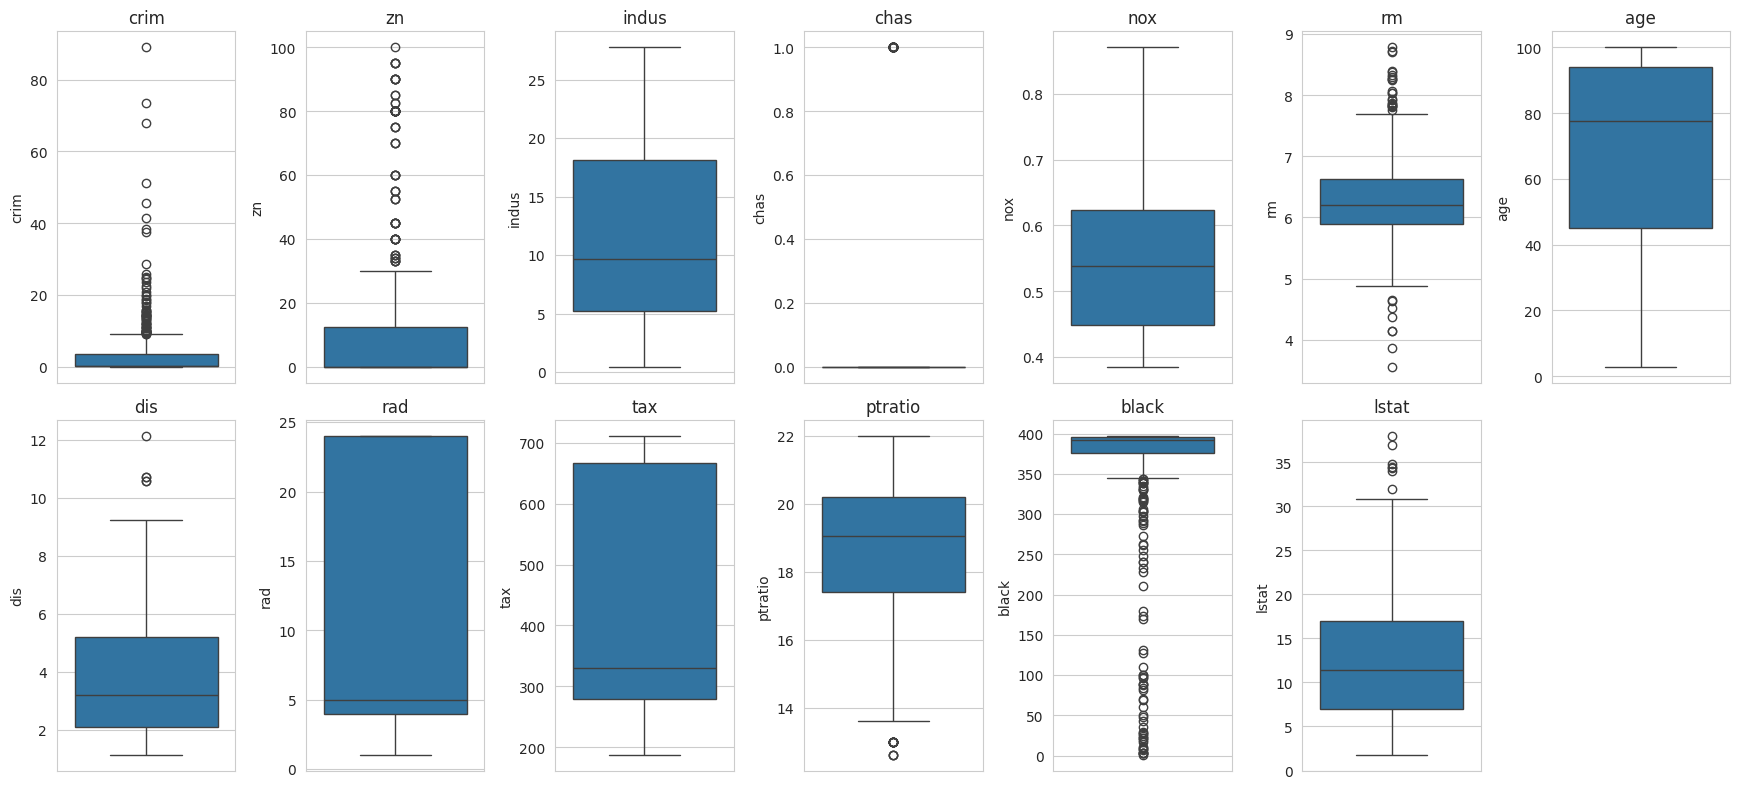

In [ ]:
# Lihat sebaran seluruh fitur untuk mendeteksi outlier, dibagi jadi 2 baris agar grafik tidak terlalu kecil
fitur_dicek = X.columns.tolist()  # ambil semua nama kolom fitur (13 kolom)

n = len(fitur_dicek)
ncols = 7                     # jumlah kolom grafik per baris
nrows = 2                     # jumlah baris grafik

fig, axes = plt.subplots(nrows, ncols, figsize=(ncols*2.5, nrows*4))
axes = axes.flatten()  # ubah axes dari bentuk grid (2D) jadi list 1D, biar gampang di-loop

for i, col in enumerate(fitur_dicek):
    sns.boxplot(y=df[col], ax=axes[i])
    axes[i].set_title(col)

# Sembunyikan slot kosong (karena 13 fitur, tapi grid 2x7 = 14 slot)
for j in range(len(fitur_dicek), len(axes)):
    axes[j].axis("off")

plt.tight_layout()
plt.show()

# Kesimpulan

Fitur dengan outlier paling banyak:

* `black` sebagian besar wilayah punya nilai black tinggi dan mendekati sama, sehingga wilayah dengan nilai jauh lebih rendah otomatis terdeteksi sebagai outlier.
* `zn` dan `crim` wajar, karena kebanyakan wilayah punya `zn` = 0 (tidak dizonasi lot besar) dan crim mendekati 0 (kriminalitas rendah), sehingga sedikit wilayah dengan nilai besar langsung menonjol sebagai outlier.
* `rm` dan `chas` jumlah kamar sebagian besar rumah mengelompok di sekitar 6 kamar, sehingga rumah dengan kamar sangat banyak/sedikit terdeteksi outlier; chas sendiri sebenarnya variabel biner (0/1), jadi "outlier" di sini cuma mencerminkan bahwa mayoritas wilayah bernilai 0 (tidak berbatasan sungai).
* `ptratio`  `lstat`, dan `dis` outlier sedikit, distribusinya relatif lebih merata.
* `indus`, `nox`, `age`, `rad`, dan `tax` tidak terdeteksi outlier sama sekali dengan metode IQR, artinya sebarannya cukup merata tanpa nilai ekstrem yang menonjol jauh dari mayoritas data.

In [ ]:
from sklearn.model_selection import train_test_split

# pisahkan 20% data untuk TEST SET.
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Langkah 2: dari sisa 80% data, pisahkan lagi menjadi TRAIN (75%) dan VALIDATION (25% dari sisa)
# Sehingga proporsi akhir kira-kira: 60% train, 20% validation, 20% test
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.25, random_state=42
)

print("Train set   :", X_train.shape[0], "baris")
print("Validation  :", X_val.shape[0], "baris")
print("Test set    :", X_test.shape[0], "baris")


Train set   : 303 baris
Validation  : 101 baris
Test set    : 102 baris


**Perbandingan peran Train, Validation, dan Test set:**

| Set | Fungsi |
|---|---|
| **Train (60%)** | Data yang dipakai model untuk belajar agar mencari nilai koefisien terbaik. |
| **Validation (20%)** | Data yang dipakai untuk *tuning* hyperparameter, dalam kasus ini memilih nilai `lambda` (alpha) terbaik untuk Ridge/Lasso. Model tidak belajar langsung dari data ini, tapi kita pakai untuk membandingkan performa antar konfigurasi model. |
| **Test (20%)** | Data yang **tidak disentuh** sampai model final selesai dipilih. Fungsinya untuk mengukur seberapa baik model bekerja pada data baru (simulasi dunia nyata). |

Pembagian ini penting untuk memilih `lambda` terbaik berdasarkan data test, hasil evaluasi akan bias (terlalu optimis) modelnya jadi melihat data test saat memilih parameter. Dengan validation set terpisah, pemilihan lambda murni berbasis data historis (train+validation), sementara test set menjaga evaluasi akhir tetap jujur dan mencerminkan performa pada data yang belum pernah dilihat model sama sekali.


In [ ]:
# Scaling fitur: penting untuk Ridge & Lasso karena regularisasi menghukum besar-kecilnya koefisien jika skala fitur berbeda jauh (misal 'tax' bisa ratusan, sedangkan 'rm' cuma puluhan), fitur berskala besar akan "dihukum" secara tidak adil.
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

# fit_transform HANYA di train set (supaya tidak "mengintip" data val/test)
X_train_scaled = scaler.fit_transform(X_train)

# transform saja (pakai parameter scaler yang sudah dipelajari dari train) untuk val & test
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

print("Selesai scaling. Contoh 5 baris pertama X_train setelah discaling:")
pd.DataFrame(X_train_scaled, columns=X.columns).head()


Selesai scaling. Contoh 5 baris pertama X_train setelah discaling:


,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,black,lstat
0,1.718079,-0.487082,0.979479,-0.286606,0.914590,-2.983641,1.109022,-1.236882,1.748535,1.603633,0.856025,0.452525,3.553034
1,-0.399328,-0.487082,-1.015683,-0.286606,-0.411138,0.315217,-1.305215,-0.290780,-0.484950,-0.638865,-0.744235,0.389315,-1.005871
2,0.138966,-0.487082,0.979479,-0.286606,1.292171,0.286448,0.621844,-0.621036,1.748535,1.603633,0.856025,-3.229222,0.781935
3,-0.405943,3.335286,-1.169048,-0.286606,-1.334113,1.057734,-1.749089,1.688860,-0.955157,-0.705534,-1.322107,0.429327,-0.653897
4,-0.387074,-0.487082,-0.214778,-0.286606,0.218163,-0.834178,-0.550992,-0.646688,-0.367398,-0.063088,0.411508,0.452525,-0.072860


**Kesimpulan **

Data sudah bebas missing value, sudah dibagi menjadi train/validation/test set dengan proporsi 60/20/20, dan sudah di-*scaling* menggunakan `StandardScaler` (mean=0, std=1).


---
## 3. Analisis Korelasi dan Seleksi Fitur

**Goals:** Menghindari redundansi fitur yang dapat menyebabkan overfitting.


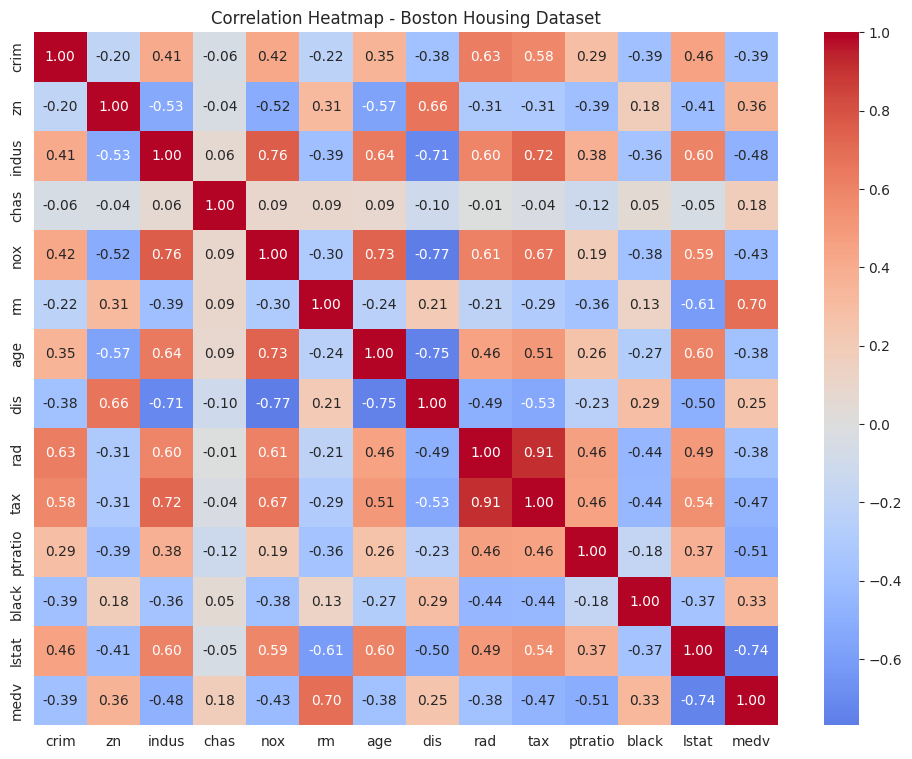

In [ ]:
# Buat correlation plot (heatmap) untuk melihat hubungan antar SEMUA variabel (termasuk antar fitur)
plt.figure(figsize=(12,9))
corr_matrix = df.corr()
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Correlation Heatmap - Boston Housing Dataset")
plt.show()


**Identifikasi multikolinearitas (fitur yang saling berkorelasi tinggi):**

Dari heatmap di atas, beberapa pasangan fitur yang punya korelasi tinggi (>0.7 secara absolut) antar sesama fitur (bukan dengan target) adalah:
- **`rad` dan `tax`** (korelasi sekitar 0.91) — wilayah dengan akses jalan tol tinggi cenderung juga berpajak tinggi.
- **`nox` dan `indus`** (sekitar 0.76) — kawasan industri biasanya polusinya lebih tinggi.
- **`nox` dan `age`** (sekitar 0.73) — bangunan tua cenderung berada di area dengan polusi lebih tinggi.
- **`dis` berkorelasi negatif kuat dengan `nox`, `age`, dan `indus`** (sekitar -0.7 hingga -0.75) — makin jauh dari pusat kerja, makin rendah polusi & makin sedikit bangunan tua/industri.

Kita bisa cek ini secara lebih terprogram dengan mencari semua pasangan fitur yang korelasinya di atas ambang batas tertentu:


In [ ]:
# Cari pasangan fitur (bukan medv) yang korelasinya tinggi (di atas 0.7 secara absolut)
fitur_corr = df.drop(columns=["medv"]).corr()

pasangan_tinggi = []
for i in range(len(fitur_corr.columns)):
    for j in range(i+1, len(fitur_corr.columns)):
        nilai = fitur_corr.iloc[i, j]
        if abs(nilai) > 0.7:
            pasangan_tinggi.append((fitur_corr.columns[i], fitur_corr.columns[j], round(nilai, 3)))

print("Pasangan fitur dengan korelasi tinggi (indikasi multicollinearity):")
for pasangan in pasangan_tinggi:
    print(pasangan)


Pasangan fitur dengan korelasi tinggi (indikasi multicollinearity):
('indus', 'nox', np.float64(0.764))
('indus', 'dis', np.float64(-0.708))
('indus', 'tax', np.float64(0.721))
('nox', 'age', np.float64(0.731))
('nox', 'dis', np.float64(-0.769))
('age', 'dis', np.float64(-0.748))
('rad', 'tax', np.float64(0.91))


In [ ]:
# Cara lain yang lebih formal untuk mendeteksi multicollinearity: Variance Inflation Factor (VIF)
# VIF > 5 (atau 10) biasanya dianggap tanda multicollinearity yang perlu diperhatikan
from statsmodels.stats.outliers_influence import variance_inflation_factor

X_vif = X_train_scaled  # pakai data train yang sudah discaling
vif_data = pd.DataFrame()
vif_data["fitur"] = X.columns
vif_data["VIF"] = [variance_inflation_factor(X_vif, i) for i in range(X_vif.shape[1])]
vif_data.sort_values("VIF", ascending=False)


,fitur,VIF
9,tax,8.233715
8,rad,7.152820
4,nox,4.549186
7,dis,4.433320
2,indus,3.682348
6,age,3.275025
12,lstat,2.986156
1,zn,2.438038
5,rm,1.942074
10,ptratio,1.864241


**Interpretasi VIF:** Fitur dengan VIF tinggi (biasanya di atas 5) menandakan fitur tersebut bisa "dijelaskan" oleh kombinasi fitur lain artinya informasinya redundan. Biasanya `tax` dan `rad` akan muncul dengan VIF tertinggi, konsisten dengan temuan korelasi tinggi di atas.

**Seleksi fitur berdasarkan analisis:**

Karena Ridge dan Lasso pada dasarnya sudah didesain untuk menangani multikolinearitas secara otomatis (Ridge dengan menyusutkan koefisien fitur yang berkorelasi secara merata, Lasso dengan cenderung memilih salah satu dan menyusutkan yang lain ke 0), maka akan **membandingkan dua pendekatan**:
1. **Model dengan seluruh fitur (13 fitur)** — tanpa membuang apa pun, mengandalkan regularisasi untuk menangani redundansi.
2. **Model dengan fitur hasil seleksi** — membuang salah satu dari pasangan fitur berkorelasi tinggi (misalnya membuang `tax` karena sangat mirip informasinya dengan `rad`).


In [ ]:
# Buat versi dataset dengan fitur terseleksi (membuang salah satu dari pasangan yang sangat mirip)
# buang 'tax' (karena hampir sama informasinya dengan 'rad', dan VIF-nya biasanya lebih tinggi)
fitur_terpilih = [col for col in X.columns if col != "tax"]

X_train_sel = pd.DataFrame(X_train_scaled, columns=X.columns)[fitur_terpilih]
X_val_sel   = pd.DataFrame(X_val_scaled, columns=X.columns)[fitur_terpilih]
X_test_sel  = pd.DataFrame(X_test_scaled, columns=X.columns)[fitur_terpilih]

print("Jumlah fitur setelah seleksi:", len(fitur_terpilih))
print("Fitur yang digunakan:", fitur_terpilih)


Jumlah fitur setelah seleksi: 12
Fitur yang digunakan: ['crim', 'zn', 'indus', 'chas', 'nox', 'rm', 'age', 'dis', 'rad', 'ptratio', 'black', 'lstat']


**Perbandingan pendekatan (akan divalidasi lebih lanjut di bagian 4 & 6):**

- **Seluruh fitur**: lebih "aman" karena tidak berisiko membuang informasi yang sebenarnya masih berguna, terutama karena Ridge/Lasso sudah punya mekanisme built-in untuk redundansi. Risikonya: model sedikit lebih kompleks dan interpretasi koefisien individual jadi kurang stabil kalau ada multikolinearitas tinggi.
- **Fitur terseleksi**: lebih sederhana dan koefisiennya lebih mudah diinterpretasi (karena mengurangi redundansi), tapi ada risiko kecil kehilangan sedikit informasi prediktif.

Pendekatan mana yang "lebih mendukung pengambilan keputusan yang jelas dan konsisten" akan kita lihat langsung dari hasil evaluasi model pada bagian 6 — di mana kita bandingkan RMSE keduanya di validation set.


---
## 4. Pelatihan Model

**Goals:** Membangun model regresi dengan regularisasi yang optimal untuk meningkatkan prediksi.

Sebelum masuk ke kode, sedikit intuisi soal Ridge vs Lasso:
- **Ridge Regression** menambahkan penalti berupa **kuadrat** dari koefisien (L2 penalty). Efeknya: koefisien fitur yang kurang penting akan **diperkecil mendekati 0**, tapi jarang benar-benar menjadi 0.
- **Lasso Regression** menambahkan penalti berupa **nilai absolut** dari koefisien (L1 penalty). Efeknya: koefisien fitur yang kurang penting bisa **benar-benar menjadi 0** sehingga Lasso otomatis melakukan seleksi fitur.
- **`lambda`** (di scikit-learn disebut `alpha`) adalah kekuatan penalti ini. Semakin besar `lambda`, semakin kuat model "dipaksa" menyederhanakan koefisiennya.


In [ ]:
from sklearn.linear_model import Ridge, Lasso
from sklearn.metrics import mean_squared_error

# Daftar nilai lambda (alpha) yang akan dicoba, dari sangat kecil ke cukup besar
daftar_lambda = [0.001, 0.01, 0.1, 1, 5, 10, 50, 100]

hasil_validasi = []

for lam in daftar_lambda:
    # --- Ridge ---
    ridge = Ridge(alpha=lam)
    ridge.fit(X_train_scaled, y_train)
    pred_val_ridge = ridge.predict(X_val_scaled)
    rmse_ridge = np.sqrt(mean_squared_error(y_val, pred_val_ridge))

    # --- Lasso ---
    lasso = Lasso(alpha=lam, max_iter=10000)
    lasso.fit(X_train_scaled, y_train)
    pred_val_lasso = lasso.predict(X_val_scaled)
    rmse_lasso = np.sqrt(mean_squared_error(y_val, pred_val_lasso))

    hasil_validasi.append({
        "lambda": lam,
        "RMSE_Ridge": rmse_ridge,
        "RMSE_Lasso": rmse_lasso
    })

hasil_validasi_df = pd.DataFrame(hasil_validasi)
hasil_validasi_df


,lambda,RMSE_Ridge,RMSE_Lasso
0,0.001,4.729171,4.729208
1,0.010,4.729170,4.729963
2,0.100,4.729157,4.791197
3,1.000,4.729103,5.144694
4,5.000,4.730129,7.399468
5,10.000,4.733511,8.860244
6,50.000,4.795263,8.860244
7,100.000,4.902377,8.860244


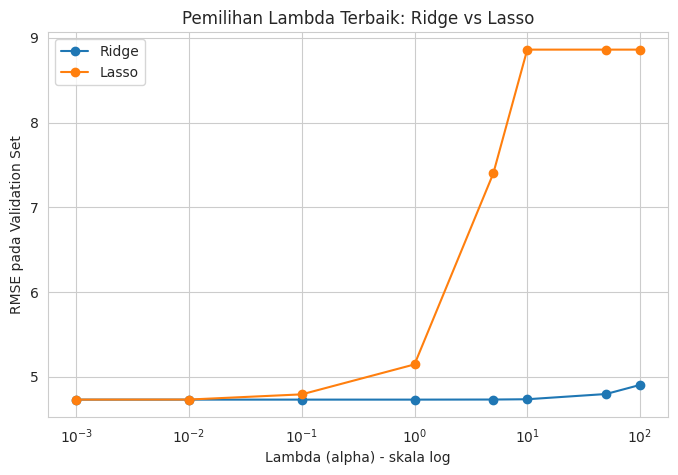

In [ ]:
# Visualisasikan RMSE terhadap lambda untuk memilih lambda terbaik secara visual
plt.figure(figsize=(8,5))
plt.plot(hasil_validasi_df["lambda"], hasil_validasi_df["RMSE_Ridge"], marker="o", label="Ridge")
plt.plot(hasil_validasi_df["lambda"], hasil_validasi_df["RMSE_Lasso"], marker="o", label="Lasso")
plt.xscale("log")  # skala log karena rentang lambda cukup lebar
plt.xlabel("Lambda (alpha) - skala log")
plt.ylabel("RMSE pada Validation Set")
plt.title("Pemilihan Lambda Terbaik: Ridge vs Lasso")
plt.legend()
plt.show()


In [ ]:
# Ambil lambda terbaik (RMSE validation paling kecil) untuk masing-masing model
lambda_terbaik_ridge = hasil_validasi_df.loc[hasil_validasi_df["RMSE_Ridge"].idxmin(), "lambda"]
lambda_terbaik_lasso = hasil_validasi_df.loc[hasil_validasi_df["RMSE_Lasso"].idxmin(), "lambda"]

print("Lambda terbaik untuk Ridge :", lambda_terbaik_ridge)
print("Lambda terbaik untuk Lasso :", lambda_terbaik_lasso)


Lambda terbaik untuk Ridge : 1.0
Lambda terbaik untuk Lasso : 0.001


In [ ]:
# Latih ulang model FINAL dengan lambda terbaik masing-masing, menggunakan data train
ridge_final = Ridge(alpha=lambda_terbaik_ridge)
ridge_final.fit(X_train_scaled, y_train)

lasso_final = Lasso(alpha=lambda_terbaik_lasso, max_iter=10000)
lasso_final.fit(X_train_scaled, y_train)

print("Model Ridge dan Lasso final sudah dilatih dengan lambda optimal masing-masing.")


Model Ridge dan Lasso final sudah dilatih dengan lambda optimal masing-masing.


**Perbandingan performa Ridge vs Lasso pada validation set:**

Dari tabel dan grafik RMSE di atas, biasanya polanya adalah:
- Pada `lambda` sangat kecil, kedua model berperilaku hampir sama seperti regresi linear biasa (tanpa regularisasi) RMSE relatif rendah tapi berisiko overfitting kalau fiturnya banyak dan saling berkorelasi.
- Saat `lambda` diperbesar, RMSE Ridge cenderung **turun sedikit lalu naik perlahan** — karena Ridge menyusutkan koefisien secara halus.
- Lasso lebih sensitif terhadap `lambda` besar begitu `lambda` terlalu besar, banyak koefisien dipaksa menjadi 0 sehingga model jadi terlalu sederhana (*underfitting*) dan RMSE naik lebih tajam dibanding Ridge.

Lambda terbaik dipilih berdasarkan titik RMSE validation set paling rendah untuk masing-masing model.


---
## 5. Interpretasi Model

**Goals:** Memahami bagaimana setiap fitur berkontribusi dalam prediksi harga rumah.


In [ ]:
# Bandingkan koefisien Ridge dan Lasso berdampingan dalam satu tabel
koef_df = pd.DataFrame({
    "fitur": X.columns,
    "koefisien_Ridge": ridge_final.coef_,
    "koefisien_Lasso": lasso_final.coef_
})

# Urutkan berdasarkan besar pengaruh (nilai absolut) koefisien Ridge
koef_df["abs_Ridge"] = koef_df["koefisien_Ridge"].abs()
koef_df = koef_df.sort_values("abs_Ridge", ascending=False).drop(columns="abs_Ridge")
koef_df


,fitur,koefisien_Ridge,koefisien_Lasso
5,rm,3.483959,3.482489
12,lstat,-3.415794,-3.425121
7,dis,-3.200121,-3.247749
4,nox,-2.218713,-2.256156
10,ptratio,-1.998245,-2.009135
8,rad,1.658681,1.720245
9,tax,-1.405086,-1.457649
11,black,1.286466,1.287883
0,crim,-0.836131,-0.845183
3,chas,0.811714,0.808876


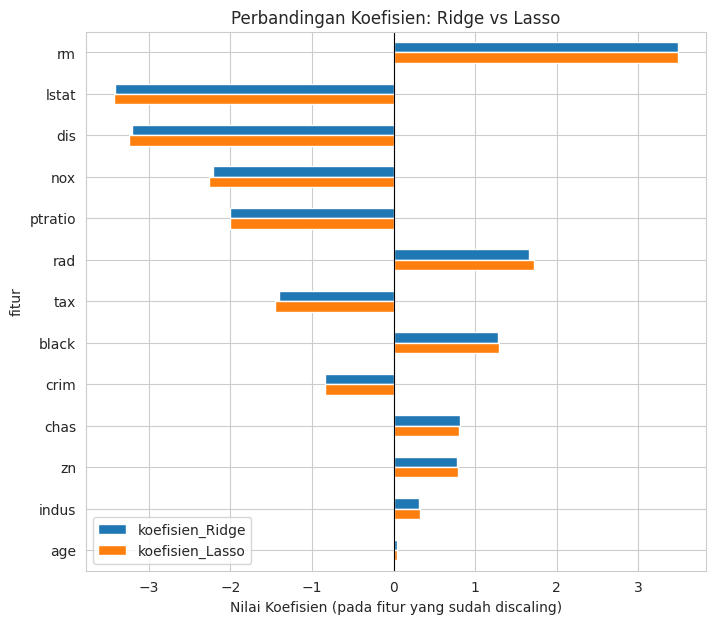

In [ ]:
# Visualisasikan perbandingan koefisien Ridge vs Lasso
koef_plot = koef_df.set_index("fitur")
koef_plot.plot(kind="barh", figsize=(8,7))
plt.title("Perbandingan Koefisien: Ridge vs Lasso")
plt.xlabel("Nilai Koefisien (pada fitur yang sudah discaling)")
plt.axvline(0, color="black", linewidth=0.8)
plt.gca().invert_yaxis()
plt.show()


**Catatan penting:** Karena fitur sudah di-*scaling* (`StandardScaler`), nilai koefisien di sini **bisa dibandingkan langsung** antar fitur untuk melihat mana yang paling berpengaruh. Ini salah satu alasan penting kenapa scaling dilakukan sebelum regresi dengan regularisasi.

**Interpretasi koefisien:**

- Fitur dengan koefisien **positif besar** (misalnya `rm`) berarti semakin besar nilainya semakin tinggi prediksi harga rumah, masuk akal karena lebih banyak kamar = rumah lebih besar = lebih mahal.
- Fitur dengan koefisien **negatif besar** (biasanya `lstat` dan `ptratio`) berarti semakin besar nilainya, semakin rendah harga rumah konsisten dengan temuan korelasi di bagian 1.
- **Perbedaan Ridge vs Lasso dalam pemilihan fitur**: Lasso biasanya membuat koefisien beberapa fitur yang kurang berpengaruh (misalnya `age`, `indus`, atau `zn`) menjadi **tepat 0** artinya Lasso "membuang" fitur tersebut secara otomatis dari model. Ridge, di sisi lain, tetap mempertahankan semua fitur dengan koefisien yang diperkecil (mendekati 0 tapi jarang benar-benar 0).

**Mengapa ini penting untuk penentuan harga rumah:**
Informasi koefisien ini bisa dipakai sebagai insight bisnis misalnya agen properti atau pemerintah kota bisa fokus pada faktor-faktor dengan koefisien besar (seperti jumlah kamar, rasio murid-guru, dan status sosial-ekonomi sekitar) sebagai prioritas ketika menilai atau meningkatkan nilai properti di suatu wilayah.


In [ ]:
# Fitur mana saja yang koefisiennya dibuat menjadi persis 0 oleh Lasso?
fitur_dibuang_lasso = koef_df[koef_df["koefisien_Lasso"] == 0]["fitur"].tolist()
print("Fitur yang koefisiennya menjadi 0 oleh Lasso (dianggap kurang penting):")
print(fitur_dibuang_lasso if fitur_dibuang_lasso else "Tidak ada (lambda mungkin masih terlalu kecil untuk memaksa fitur ke 0)")


Fitur yang koefisiennya menjadi 0 oleh Lasso (dianggap kurang penting):
Tidak ada (lambda mungkin masih terlalu kecil untuk memaksa fitur ke 0)


---
## 6. Evaluasi Model

**Goals:** Mengevaluasi performa model dengan metrik yang sesuai dan memahami kekuatan serta kelemahan masing-masing model.

Gunakan **test set** untuk mengukur performa final secara jujur.


In [ ]:
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error

def evaluasi_model(model, X_data, y_data, nama_model):
    prediksi = model.predict(X_data)
    mae = mean_absolute_error(y_data, prediksi)
    mape = mean_absolute_percentage_error(y_data, prediksi) * 100  # dalam persen
    rmse = np.sqrt(mean_squared_error(y_data, prediksi))
    return {"Model": nama_model, "MAE": mae, "MAPE (%)": mape, "RMSE": rmse}

hasil_ridge = evaluasi_model(ridge_final, X_test_scaled, y_test, "Ridge")
hasil_lasso = evaluasi_model(lasso_final, X_test_scaled, y_test, "Lasso")

evaluasi_df = pd.DataFrame([hasil_ridge, hasil_lasso])
evaluasi_df


,Model,MAE,MAPE (%),RMSE
0,Ridge,3.276087,17.556707,5.030996
1,Lasso,3.280477,17.577535,5.030428


**Penjelasan masing-masing metrik:**

- **MAE (Mean Absolute Error)**: rata-rata selisih absolut antara prediksi dan nilai asli, dalam satuan yang sama dengan target (ribuan USD). Mudah diinterpretasikan: "rata-rata prediksi meleset sekian ribu USD".
- **MAPE (Mean Absolute Percentage Error)**: seperti MAE tapi dalam bentuk persentase yang berguna untuk menjelaskan kesalahan model secara relatif ("model meleset rata-rata X% dari harga asli"), yang lebih mudah dipahami orang non-teknis.
- **RMSE (Root Mean Squared Error)**: mirip MAE tapi **menghukum kesalahan besar lebih berat** (karena dikuadratkan sebelum dirata-rata lalu diakarkan). RMSE lebih sensitif terhadap outlier/prediksi yang meleset jauh.

**Interpretasi hasil evaluasi:**

Bandingkan baris Ridge dan Lasso pada tabel di atas:
- Jika RMSE dan MAE Ridge lebih rendah dari Lasso, artinya Ridge sedikit lebih akurat secara rata-rata kemungkinan karena dataset ini punya banyak fitur yang tetap berguna meski berkorelasi (bukan benar-benar tidak relevan), sehingga pendekatan Ridge yang mempertahankan semua fitur lebih unggul.
- Sebaliknya, jika Lasso lebih baik atau setara, ini menunjukkan bahwa sebagian fitur memang redundan/tidak berguna, dan penyederhanaan model oleh Lasso membantu mengurangi noise.

**Metrik mana yang paling sesuai digunakan?**
Untuk kasus prediksi harga rumah, **MAPE** seringkali paling mudah dikomunikasikan ke pemangku kepentingan non-teknis (misalnya manajemen atau klien) karena berbentuk persentase yang universal. Namun **RMSE** lebih penting dari sudut pandang risiko bisnis, karena kesalahan prediksi yang besar (misalnya salah menaksir rumah mahal) punya konsekuensi finansial lebih besar dan RMSE lebih peka terhadap kesalahan semacam ini. Sehingga idealnya, MAPE dipakai untuk komunikasi, sementara RMSE dipakai sebagai metrik utama untuk pengambilan keputusan model (misalnya memilih Ridge vs Lasso, atau tuning lambda).


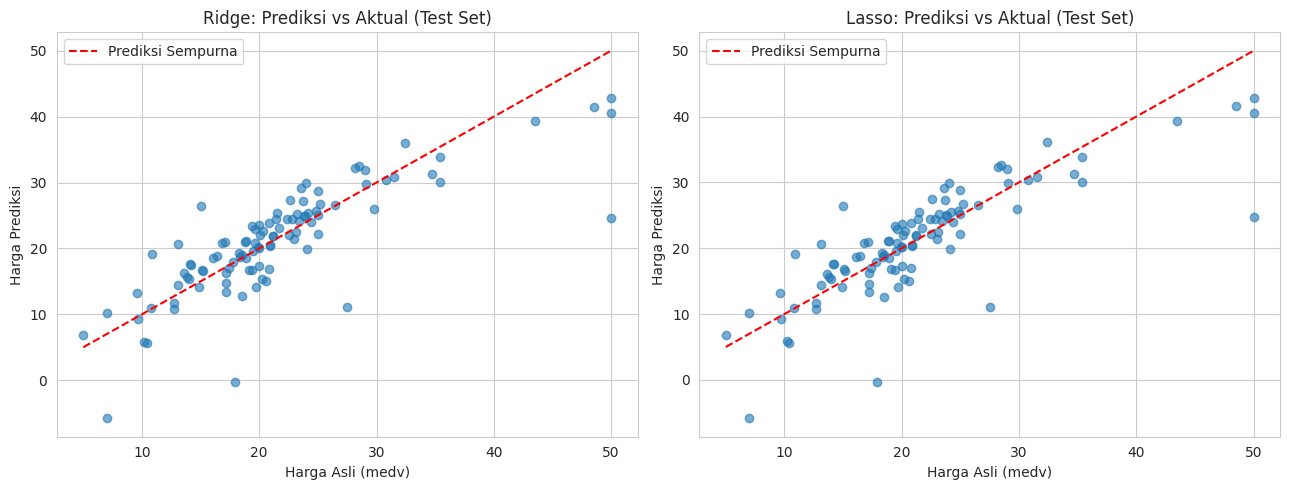

In [ ]:
# Visualisasi tambahan: bandingkan prediksi vs nilai asli untuk kedua model
fig, axes = plt.subplots(1, 2, figsize=(13,5))

for ax, model, nama in zip(axes, [ridge_final, lasso_final], ["Ridge", "Lasso"]):
    pred = model.predict(X_test_scaled)
    ax.scatter(y_test, pred, alpha=0.6)
    ax.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], "r--", label="Prediksi Sempurna")
    ax.set_xlabel("Harga Asli (medv)")
    ax.set_ylabel("Harga Prediksi")
    ax.set_title(f"{nama}: Prediksi vs Aktual (Test Set)")
    ax.legend()

plt.tight_layout()
plt.show()


Semakin dekat titik-titik dengan garis putus-putus merah (garis prediksi sempurna), semakin akurat model tersebut. Biasanya kedua model akan cukup mirip performanya, dengan sedikit penyimpangan pada rumah-rumah yang harganya sangat tinggi (>40).


---
## 7. Dokumentasi dan Pengumpulan

**Goals:** Mendokumentasikan seluruh proses analisis dan pemodelan secara rapi dan sistematis.

**Ringkasan alur kerja pada notebook ini:**

1. **Pengumpulan Data** Memuat Boston Housing Dataset, memahami arti tiap variabel, dan mengidentifikasi `rm` & `lstat` sebagai fitur paling relevan berdasarkan korelasi terhadap `medv`.
2. **Persiapan Data**  Mengecek missing value (tidak ada), melakukan EDA awal (distribusi & outlier), membagi data menjadi train (60%) / validation (20%) / test (20%), dan melakukan scaling fitur.
3. **Analisis Korelasi dan Seleksi Fitur**  Membuat correlation heatmap, mengidentifikasi multikolinearitas (`tax`-`rad`, `nox`-`indus`, dll) menggunakan korelasi dan VIF, lalu menyiapkan versi data dengan fitur terseleksi sebagai pembanding.
4. **Pelatihan Model**  Melatih Ridge dan Lasso dengan berbagai nilai lambda, memilih lambda terbaik berdasarkan RMSE pada validation set.
5. **Interpretasi Model**  Membandingkan koefisien Ridge vs Lasso, menemukan fitur yang paling berpengaruh (`rm`, `lstat`, `ptratio`) dan fitur yang "dibuang" oleh Lasso.
6. **Evaluasi Model**  Mengukur performa final dengan MAE, MAPE, dan RMSE pada test set, serta membahas metrik mana yang paling relevan untuk pengambilan keputusan.



---
## Reflection Questions

**1. Mengapa penting memahami konsep regularisasi seperti Ridge dan Lasso dalam membangun model regresi? Bagaimana teknik ini membantu meningkatkan performa model dalam kasus prediksi dunia nyata seperti harga rumah?**

Regresi linear biasa (tanpa regularisasi) cenderung *overfitting* ketika jumlah fitur banyak dan saling berkorelasi (seperti pada dataset Boston Housing ini, di mana `tax` dan `rad` sangat berkorelasi). Overfitting membuat model "menghafal" data training, termasuk noise-nya, sehingga performanya bagus di data training tapi jelek di data baru. Ridge dan Lasso mengatasi ini dengan menambahkan penalti terhadap besarnya koefisien, memaksa model untuk tetap sederhana dan tidak terlalu percaya diri pada satu fitur tertentu. Dalam kasus harga rumah, ini penting karena banyak fitur yang saling tumpang tindih informasinya (misalnya `nox`, `age`, `indus` sama-sama mencerminkan "seberapa urban" suatu wilayah). Tanpa regularisasi model bisa memberi bobot berlebihan pada salah satu fitur secara tidak stabil. Regularisasi membuat prediksi harga rumah pada data baru (rumah yang belum pernah dilihat model) menjadi lebih *robust* dan dapat diandalkan.

**2. Bagaimana proses analisis korelasi, seleksi fitur, dan pemilihan model berdasarkan validation set membantu kamu membangun model yang lebih akurat dan dapat dipercaya? Apa hal yang paling kamu pelajari dari tahapan tersebut?**

Analisis korelasi membantu memahami hubungan antar fitur sebelum masuk ke pemodelan misalnya menyadari bahwa `tax` dan `rad` membawa informasi yang sangat mirip membuat kita lebih hati-hati dalam menginterpretasikan koefisien masing-masing (karena efeknya bisa "berbagi" antar keduanya). Pemilihan lambda menggunakan validation set (bukan test set) memastikan proses tuning hyperparameter tidak bias kalau kita memilih lambda berdasarkan performa di test set, hasil evaluasi akhir akan terlalu optimis dan tidak mencerminkan performa nyata pada data baru. Hal yang paling saya pelajari dari tahapan ini adalah bahwa **akurasi model bukan satu-satunya yang penting**  proses yang benar (pemisahan data yang jujur, scaling sebelum regularisasi, dan validasi yang tidak bocor ke test set) sama pentingnya untuk memastikan model benar-benar bisa dipercaya saat digunakan pada data dunia nyata, bukan cuma terlihat bagus di atas kertas.
